# Capstone Project 2: Customer Churn Prediction for a Telecom / Subscription Business

**Business Context**  
A subscription company (telecom, streaming, SaaS) is losing customers.  
You must build a model that predicts which customers are likely to churn and identify the main drivers so marketing can act.

**Steps**
1. Create / load a realistic churn dataset
2. Exploratory analysis
3. Feature preparation
4. Train Logistic Regression + Decision Tree
5. Evaluate (Accuracy, Confusion Matrix, ROC-AUC)
6. Interpret and recommend actions


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 2000

df = pd.DataFrame({
    "tenure_months": np.random.randint(1, 72, n),
    "monthly_charges": np.round(np.random.uniform(25, 150, n), 2),
    "total_charges": None,  # will calculate
    "contract": np.random.choice(["Month-to-month", "One year", "Two year"], n, p=[0.55, 0.25, 0.2]),
    "internet_service": np.random.choice(["DSL", "Fiber", "None"], n, p=[0.35, 0.45, 0.2]),
    "tech_support": np.random.choice(["Yes", "No"], n, p=[0.3, 0.7]),
    "senior_citizen": np.random.choice([0, 1], n, p=[0.85, 0.15]),
    "num_tickets": np.random.poisson(1.5, n)
})
df["total_charges"] = (df["tenure_months"] * df["monthly_charges"] * np.random.uniform(0.9, 1.1, n)).round(2)

# Create churn label with realistic probability
logit = (-2.0
         + 0.025 * df["monthly_charges"]
         - 0.04 * df["tenure_months"]
         + 0.8 * (df["contract"] == "Month-to-month").astype(int)
         + 0.4 * (df["tech_support"] == "No").astype(int)
         + 0.3 * df["num_tickets"]
         + 0.5 * df["senior_citizen"])
prob = 1 / (1 + np.exp(-logit))
df["churn"] = (np.random.rand(n) < prob).astype(int)

print(df["churn"].value_counts(normalize=True).round(3))
print(df.head())


churn
0    0.506
1    0.494
Name: proportion, dtype: float64
   tenure_months  monthly_charges  total_charges        contract  \
0             52            56.83        2912.16        One year   
1             15           130.11        2107.53        Two year   
2             61            29.80        1824.80  Month-to-month   
3             21           137.72        2895.51  Month-to-month   
4             24            82.68        1810.59  Month-to-month   

  internet_service tech_support  senior_citizen  num_tickets  churn  
0             None           No               0            2      0  
1              DSL           No               0            3      1  
2            Fiber           No               0            3      0  
3            Fiber          Yes               0            2      1  
4            Fiber           No               0            1      1  


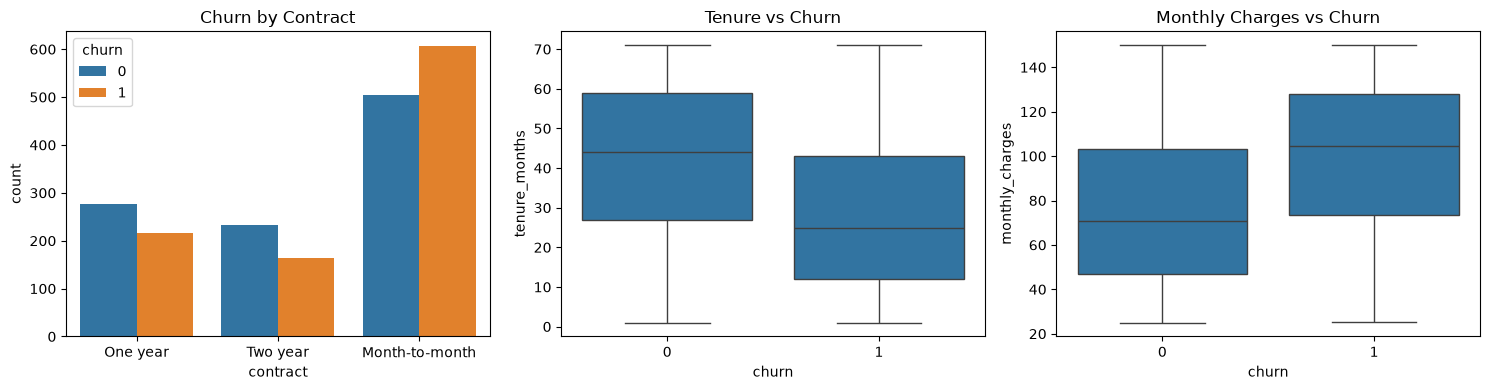

In [2]:
# Quick EDA
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="contract", hue="churn", ax=axes[0])
axes[0].set_title("Churn by Contract")
sns.boxplot(data=df, x="churn", y="tenure_months", ax=axes[1])
axes[1].set_title("Tenure vs Churn")
sns.boxplot(data=df, x="churn", y="monthly_charges", ax=axes[2])
axes[2].set_title("Monthly Charges vs Churn")
plt.tight_layout()
plt.show()


In [3]:
# Prepare features
df_ml = pd.get_dummies(df, columns=["contract", "internet_service", "tech_support"], drop_first=True)
X = df_ml.drop(columns=["churn", "total_charges"])  # total_charges highly correlated with tenure
y = df_ml["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
num_cols = ["tenure_months", "monthly_charges", "num_tickets"]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Models
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

for name, model in [("Logistic Regression", logreg), ("Decision Tree", tree)]:
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    print(f"\n=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_test, pred), 3))
    print("ROC-AUC :", round(roc_auc_score(y_test, prob), 3))
    print(confusion_matrix(y_test, pred))



=== Logistic Regression ===
Accuracy: 0.698
ROC-AUC : 0.788
[[193  60]
 [ 91 156]]

=== Decision Tree ===
Accuracy: 0.7
ROC-AUC : 0.748
[[169  84]
 [ 66 181]]


In [4]:
# Feature importance / coefficients for storytelling
coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
print("Logistic Regression Coefficients (impact on churn log-odds):")
print(coef.round(3))

print("\nDecision Tree Feature Importances:")
print(pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False).round(3))


Logistic Regression Coefficients (impact on churn log-odds):
tenure_months            -0.865
contract_Two year        -0.836
contract_One year        -0.779
tech_support_Yes         -0.551
internet_service_None    -0.210
internet_service_Fiber   -0.083
num_tickets               0.335
senior_citizen            0.356
monthly_charges           0.856
dtype: float64

Decision Tree Feature Importances:
monthly_charges           0.507
tenure_months             0.435
num_tickets               0.035
tech_support_Yes          0.013
senior_citizen            0.011
contract_One year         0.000
contract_Two year         0.000
internet_service_Fiber    0.000
internet_service_None     0.000
dtype: float64


---
## Business Recommendations (example)

1. **Month-to-month contracts** are the strongest churn driver → incentivise longer contracts with discounts.
2. **High monthly charges + low tenure** customers are high-risk → offer loyalty credits in the first 6 months.
3. **Customers with many support tickets** churn more → improve first-call resolution and proactive outreach.
4. Deploy the model to score the entire base weekly and feed a “Save” campaign list to the retention team.
